In [1]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
import json
warnings.filterwarnings('ignore')

#display charts directly in Jupyter
%matplotlib inline  

#==========Section 1==========#

#Load data
movies  = pd.read_csv('tmdb_5000_movies.csv', 
                     on_bad_lines='skip', #skip row with formatting errors
                     engine = 'python') #use python parser for better error tolerance
credits = pd.read_csv('tmdb_5000_credits.csv',
                     on_bad_lines='skip', #skip row with formatting errors
                     engine = 'python') #use python parser for better error tolerance

print("movies shape:", movies.shape)
print('credits shape:', credits.shape)

movies.head(3)

movies shape: (1571, 20)
credits shape: (1154, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [3]:
#=========Section2==========#

#Data Cleaning

#Check the basic info and missing values of the movies dataset
print(movies.info())
print(movies.isnull().sum())

#Check the basic info and missing values of the credits dataset
print(credits.info())
print(credits.isnull().sum())

#Convert budget and revenue to numeric ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                1571 non-null   int64  
 1   genres                1571 non-null   object 
 2   homepage              725 non-null    object 
 3   id                    1571 non-null   int64  
 4   keywords              1571 non-null   object 
 5   original_language     1571 non-null   object 
 6   original_title        1571 non-null   object 
 7   overview              1571 non-null   object 
 8   popularity            1571 non-null   float64
 9   production_companies  1571 non-null   object 
 10  production_countries  1571 non-null   object 
 11  release_date          1571 non-null   object 
 12  revenue               1571 non-null   int64  
 13  runtime               1571 non-null   int64  
 14  spoken_languages      1571 non-null   object 
 15  status               

Data Dictionary for tmdb_5000_movies.csv
Columns:
- budget: The production cost of a movie in US dollars. Integer type, no missing values.
- genres: Stored in JSON format, containing id (a unique numeric code for the genre) 
  and name (the actual genre name). String type, no missing values. 
  Requires parsing with ast.literal_eval() to extract genre names.
- homepage: Contains URLs to official movie websites. Over 50% of values are missing 
  (846 out of 1571), and URLs provide no predictive value for revenue. Dropped.
- id: A unique TMDB identifier for each movie. Integer type, no missing values. 
  Used as a key to merge with credits.csv.
- keywords: Stored in JSON format, containing id (a unique numeric code for the keyword) 
  and name (the actual keyword name). More specific than genres, describing the movie's 
  themes, plot, and style. String type, no missing values. 
  Requires parsing with ast.literal_eval() to extract keyword names.
- original_language: The original language of the movie. String type, no missing values.
- original_title: The original title of the movie. String type, no missing values.
- overview: A short plot summary of the movie. String type, no missing values.
- popularity: A TMDB-generated score reflecting a movie's overall public interest, 
  based on factors such as page views, watchlist additions, and rating activity. 
  Float type, no missing values. Expected to be a strong predictor of revenue.
- production_companies: The companies involved in producing the movie. 
  Stored in JSON format. String type, no missing values.
- production_countries: The countries where the movie was produced. 
  Stored in JSON format. String type, no missing values.
- release_date: The official release date of the movie. Originally stored as string type, 
  converted to datetime format for time-based analysis.
- revenue: The total worldwide box office revenue in US dollars. Integer type, 
  no missing values. This is the **target variable** for our prediction models. 
  Rows with revenue = 0 are removed as they indicate missing data.
- runtime: The duration of the movie in minutes. Integer type, no missing values.
- spoken_languages: The languages spoken in the movie. 
  Stored in JSON format. String type, no missing values.
- status: The release status of the movie (e.g., Released, Post Production). 
  String type, no missing values.
- tagline: A short promotional phrase for the movie. 
  85 missing values. Dropped as it provides no direct predictive value.
- title: The English title of the movie. String type, no missing values.
- vote_average: The average user rating of the movie on TMDB, on a scale of 0 to 10. 
  Float type, no missing values.
- vote_count: The total number of user ratings submitted on TMDB. 
  Integer type, no missing values.

In [4]:
#Convert release_date from string to datetime for time-based analysis
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

#Remove rows where revenue = 0 (indicates missing data, not actual zero revenue)
movies = movies[movies['revenue'] > 0]

#Remove rows where budget = 0 (indicates missing data, not actual budget)
movies = movies[movies['budget'] > 0]

#Drop homepage column as 846 missing values, URLs provide no predictive value)
#Drop tagline column (85 missing values, I think text-based sentiment analysis is beyond the scope of this project)
movies.drop(columns=['homepage', 'tagline'], inplace=True)

#Remove outliers in revenue using IQR method
Q1 = movies['revenue'].quantile(0.25)
Q3 = movies['revenue'].quantile(0.75)
IQR = Q3 - Q1

movies = movies[
    (movies['revenue'] >= Q1 - 1.5 * IQR) & (movies['revenue'] <= Q3 + 1.5 * IQR)
]
pd.options.display.float_format = '{:,.0f}'.format
print("Shape after cleaning:", movies.shape)
print("\nRevenue statistics after cleaning: ")
print(movies['revenue'].describe())

Shape after cleaning: (1306, 18)

Revenue statistics after cleaning: 
count         1,306
mean    156,838,584
std     126,617,923
min             103
25%      58,500,280
50%     122,739,325
75%     216,694,148
max     563,749,323
Name: revenue, dtype: float64


In [5]:
#==========Section3： Parse JSON Columns===========#

#Define a helper function to safely parse JSON-formatted strings
def safe_parse(x):
    try:
        return json.loads(x)
    except:
        return []

#Parse genres and extract genre names
movies['genres'] = movies['genres'].apply(safe_parse)
movies['genre_list'] = movies['genres'].apply(
    lambda x: [d['name'] for d in x] if isinstance(x, list) else []
)

#Parse keywords and extract keyword names
movies['keywords'] = movies['keywords'].apply(safe_parse)
movies['keyword_list'] = movies['keywords'].apply(
    lambda x: [d['name'] for d in x] if isinstance(x, list) else []
)

#Parse production countries and extract country names
movies['production_countries'] = movies['production_countries'].apply(safe_parse)
movies['production_country_list'] = movies['production_countries'].apply(
    lambda x: [d['name'] for d in x] if isinstance(x, list) else []
)

# Parse production companies and extract company names
movies['production_companies']    = movies['production_companies'].apply(safe_parse)
movies['production_company_list'] = movies['production_companies'].apply(
    lambda x: [d['name'] for d in x] if isinstance(x, list) else []
)

#Parse spoken language and extract language names
movies['spoken_languages'] = movies['spoken_languages'].apply(safe_parse)
movies['spoken_languages_list'] = movies['spoken_languages'].apply(
    lambda x: [d['name'] for d in x] if isinstance(x, list) else []
) 

print("Sample genre_list:", movies['genre_list'].head(3).tolist())
print("Sample keyword_list:", movies['keyword_list'].head(3).tolist())
print(movies.shape)

Sample genre_list: [['Action', 'Adventure', 'Science Fiction'], ['Adventure', 'Fantasy', 'Action', 'Science Fiction'], ['Action', 'Adventure', 'Western']]
Sample keyword_list: [['based on novel', 'mars', 'medallion', 'space travel', 'princess', 'alien', 'steampunk', 'martian', 'escape', 'edgar rice burroughs', 'alien race', 'superhuman strength', 'mars civilization', 'sword and planet', '19th century', '3d'], ['saving the world', 'dc comics', 'invulnerability', 'sequel', 'superhero', 'based on comic book', 'kryptonite', 'super powers', 'superhuman strength', 'lex luthor'], ['texas', 'horse', 'survivor', 'texas ranger', 'partner', 'outlaw', 'escape', 'lawyer', 'train', 'lone ranger', 'comanche', 'the lone ranger', 'tonto']]
(1306, 23)


In [6]:
#Merge credits into movies using id
movies['id'] = movies['id'].astype(str)
credits['movie_id'] = credits['movie_id'].astype(str)

movies = movies.merge(credits[['movie_id', 'cast','crew']],
                     left_on='id', right_on='movie_id',
                     how='left')
#Parse cast and extract top 3 actor names
movies['cast'] = movies['cast'].apply(safe_parse)
movies['cast_list'] = movies['cast'].apply(
    lambda x: [d['name'] for d in x[:3]] if isinstance(x, list) else []
)

#Parse crew and extract and extract director name
movies['crew'] = movies['crew'].apply(safe_parse)
movies['director'] = movies['crew'].apply(
    lambda x: next((d['name'] for d in x if d['job'] == 'Director'), None)
)

print("Sample cast_list:", movies['cast_list'].head(3).tolist())
print("Sample director:", movies['director'].head(3).tolist())
print("Sample after merging credits:", movies.shape)

Sample cast_list: [['Taylor Kitsch', 'Lynn Collins', 'Samantha Morton'], ['Brandon Routh', 'Kevin Spacey', 'Kate Bosworth'], ['Johnny Depp', 'Armie Hammer', 'William Fichtner']]
Sample director: ['Andrew Stanton', 'Bryan Singer', 'Gore Verbinski']
Sample after merging credits: (1306, 28)


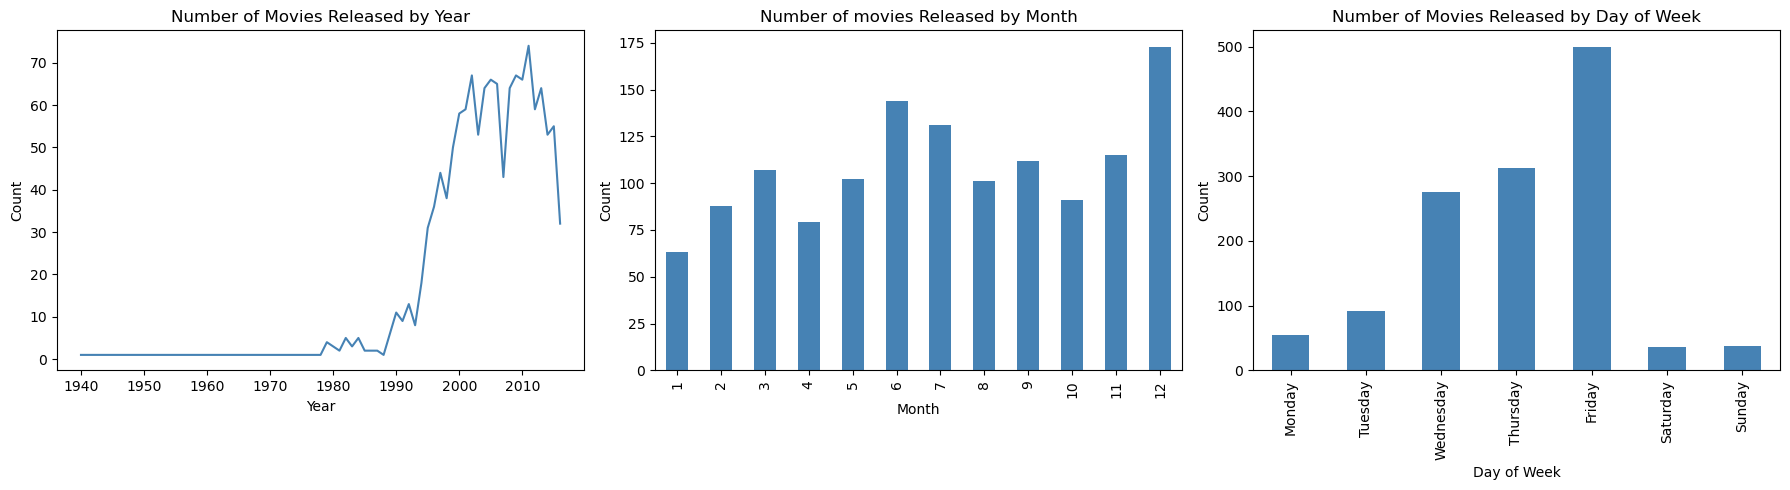

In [7]:
#Section 4: EDA && Visualizations

#Extract time-based features from release_date
movies['release_year'] = movies['release_date'].dt.year
movies['release_month'] = movies['release_date'].dt.month
movies['release_dayofweek'] = movies['release_date'].dt.day_name()

#01 Movies released by year/month/day of week
fig, axes = plt.subplots(1, 3, figsize=(18,5))

#By year
movies['release_year'].value_counts().sort_index().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Number of Movies Released by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

#By month
movies['release_month'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Number of movies Released by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

#By day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

movies['release_dayofweek'].value_counts().reindex(day_order, fill_value=0).plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Number of Movies Released by Day of Week')
axes[2].set_xlabel('Day of Week')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

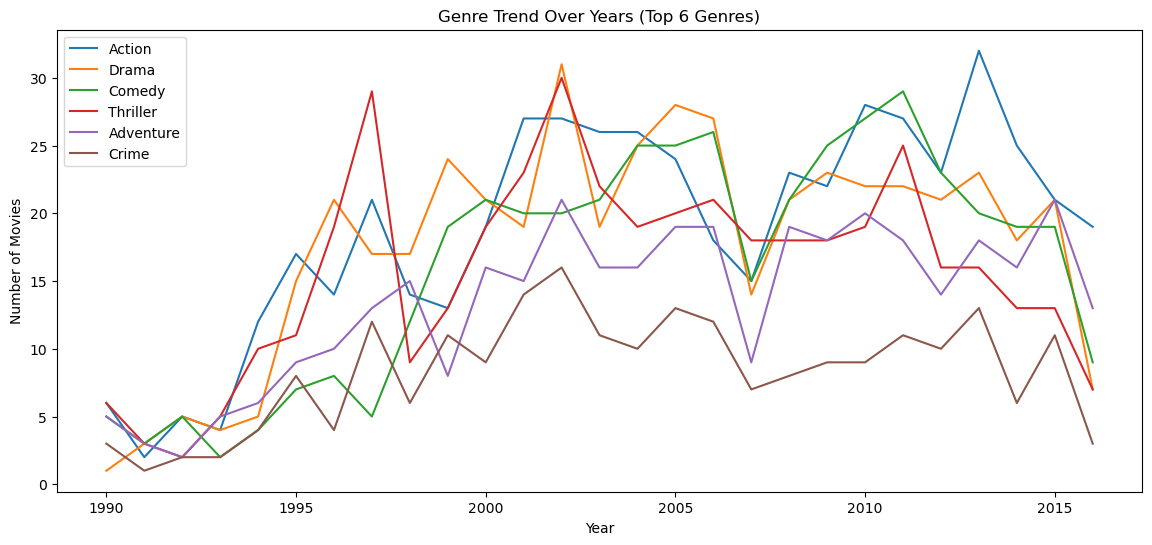

In [8]:
#02 Genre Trend Over Years
from collections import Counter

#Explode genre_list so each genre gets its own row
movies_exploded = movies.explode('genre_list')
movies_exploded = movies_exploded[movies_exploded['release_year'] >= 1990]

genre_trend = movies_exploded.groupby(['release_year','genre_list']).size().reset_index(name='count')

#Select top 6 most common genres
top_genres = movies_exploded['genre_list'].value_counts().head(6).index.tolist()

plt.figure(figsize=(14,6))
for genre in top_genres:
    subset = genre_trend[genre_trend['genre_list'] == genre]
    plt.plot(subset['release_year'], subset['count'], label=genre)

plt.title('Genre Trend Over Years (Top 6 Genres)')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.legend()
plt.show()

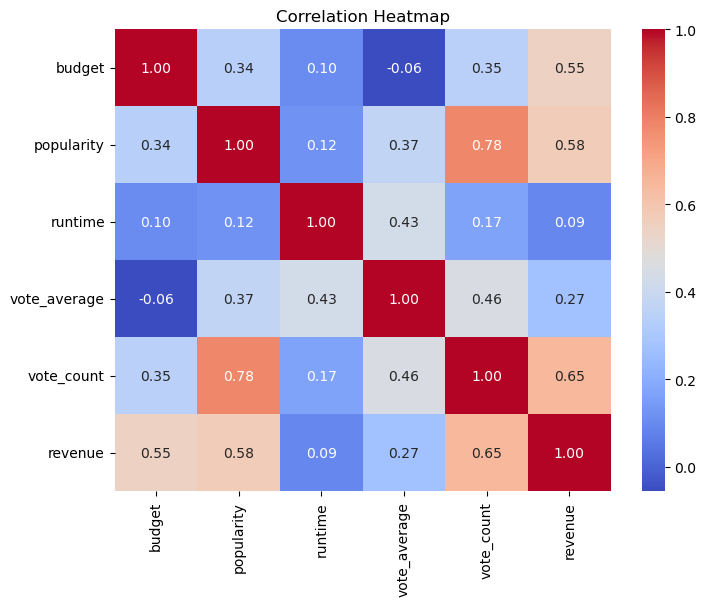

Correlation with Revenue:
revenue         1.000000
vote_count      0.647791
popularity      0.575131
budget          0.546501
vote_average    0.272496
runtime         0.089133
Name: revenue, dtype: float64


In [9]:
#03 Correlation with Revenue

numeric_cols = ['budget','popularity','runtime','vote_average','vote_count','revenue']
corr_matrix = movies[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#reset float display format to show decimals
pd.options.display.float_format = None

#Print correlation with revenue specifically
print("Correlation with Revenue:")
print(corr_matrix['revenue'].sort_values(ascending=False))


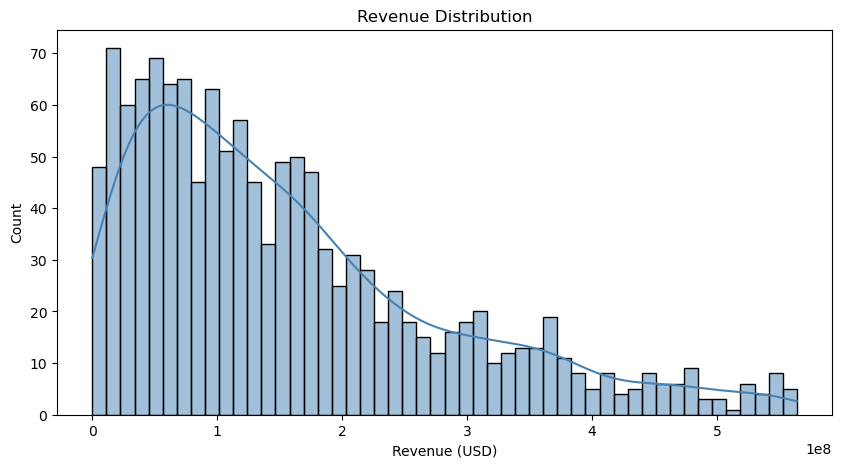

In [10]:
#04 Revenue Distribution
plt.figure(figsize=(10,5))
sns.histplot(movies['revenue'], bins=50, kde=True, color='steelblue')
plt.title('Revenue Distribution')
plt.xlabel('Revenue (USD)')
plt.ylabel('Count')
plt.show()

In [11]:
#Section5： Feature Extraction

#Extract number of genres per movie
movies['num_genres'] = movies['genre_list'].apply(len)
#Extract number of production companies per movie
movies['num_companies'] = movies['production_company_list'].apply(len)
#Extract number of production countries per movie
movies['num_countries'] = movies['production_country_list'].apply(len)
#Extract number of spoken languages per movie
movies['num_languages'] = movies['spoken_languages_list'].apply(len)
#Extract number of keywords per movie
movies['num_keywords'] = movies['keyword_list'].apply(len)
#Extract release year and month as numeric features
movies['release_year'] = movies['release_date'].dt.year
movies['release_month'] = movies['release_date'].dt.month

print("New feature added")
print(movies[['num_genres', 'num_companies', 'num_countries', 'num_languages','num_keywords','release_year','release_month']].head())

New feature added
   num_genres  num_companies  num_countries  num_languages  num_keywords  \
0           3              1              1              1            16   
1           4              4              1              3            10   
2           3              6              1              1            13   
3           3              7              4              1            12   
4           2              4              2              2             8   

   release_year  release_month  
0          2012              3  
1          2006              6  
2          2013              7  
3          2008              5  
4          2010              5  


In [12]:
feature_cols = ['budget', 'popularity', 'runtime', 'vote_average','vote_count','num_genres','num_companies','num_countries','num_languages','num_keywords','release_year','release_month']

target_col = 'revenue'

#Drop rows with any missing values in selected features
model_data = movies[feature_cols + [target_col]].dropna()

print("Final dataset shape for modeling:", model_data.shape)
print(model_data.head())

Final dataset shape for modeling: (1306, 13)
      budget  popularity  runtime  vote_average  vote_count  num_genres  \
0  260000000   43.926995      132           6.1        2124           3   
1  270000000   57.925623      154           5.4        1400           4   
2  255000000   49.046956      149           5.9        2311           3   
3  225000000   53.978602      150           6.3        1630           3   
4  200000000   37.668301      140           6.2        1398           2   

   num_companies  num_countries  num_languages  num_keywords  release_year  \
0              1              1              1            16          2012   
1              4              1              3            10          2006   
2              6              1              1            13          2013   
3              7              4              1            12          2008   
4              4              2              2             8          2010   

   release_month    revenue  
0    

In [13]:
#Session 6： Train/Test/Cross-Validation Split:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = model_data[feature_cols]
y = model_data[target_col]

#First split: 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Second split: 80% train, 20$ cross-validation from the train+val set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("Training set size: ", X_train.shape)
print("Cross-validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

#Normalize features using StandarScaler - fit only on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Training set size:  (835, 12)
Cross-validation set size: (209, 12)
Test set size: (262, 12)


In [14]:
#Section 7: Modeling
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Model 1: Linear Regression
# Assumes a linear relationship between features and revenue.
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred_val = lr_model.predict(X_val_scaled)
lr_pred_test = lr_model.predict(X_test_scaled)


# Model 2: Random Forest
# For non-linear relationships
# An ensemble of decision trees that reduces overfitting by averaging predictions from multiple trees 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred_val = rf_model.predict(X_val_scaled)
rf_pred_test = rf_model.predict(X_test_scaled)


#Model 3: XGBoost
# For tabular data
# A gradient boosting algorithm that builds trees sequentially, each correcting the errors of the previous one. 
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, subsample=0.8, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred_val = xgb_model.predict(X_val_scaled)
xgb_pred_test = xgb_model.predict(X_test_scaled)

print("All models trained successfully!")

All models trained successfully!


In [15]:
#Section 8 Evaluation
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    rse = rmse / np.std(y_true)
    print(f"Model :{name}")
    print(f"RMSE  :${rmse:,.0f}")
    print(f"RSE   :{rse:.4F}")
    print(f"R²    :{r2:.4f}")

print("\n--- Validation Set ---")
evaluate_model("Linear Regression", y_val, lr_pred_val)
evaluate_model("Random Forest", y_val, rf_pred_val)
evaluate_model("XGBoost", y_val, xgb_pred_val)

print("\n--- Test Set ---")
evaluate_model("Linear Regression", y_test, lr_pred_test)
evaluate_model("Random Forest", y_test, rf_pred_test)
evaluate_model("XGBoost", y_test, xgb_pred_test)


--- Validation Set ---
Model :Linear Regression
RMSE  :$86,474,524
RSE   :0.7363
R²    :0.4579
Model :Random Forest
RMSE  :$72,044,587
RSE   :0.6134
R²    :0.6237
Model :XGBoost
RMSE  :$70,820,810
RSE   :0.6030
R²    :0.6364

--- Test Set ---
Model :Linear Regression
RMSE  :$81,976,417
RSE   :0.6839
R²    :0.5322
Model :Random Forest
RMSE  :$80,009,477
RSE   :0.6675
R²    :0.5544
Model :XGBoost
RMSE  :$80,357,526
RSE   :0.6704
R²    :0.5505


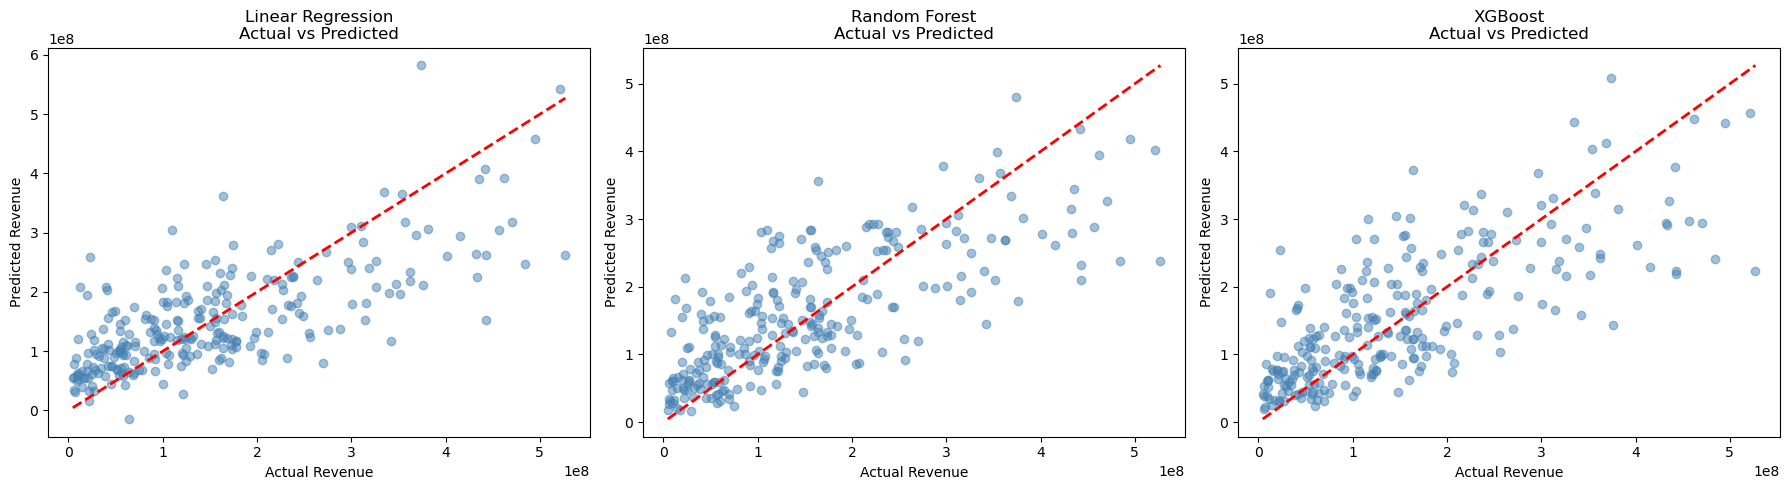

In [16]:
#Section 9 Models Comparison Visualization

#01 Actual vs Predicted Revenue
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = {
    'Linear Regression': lr_pred_test,
    'Random Forest': rf_pred_test,
    'XGBoost': xgb_pred_test
}

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_test, pred, alpha=0.5, color='steelblue')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2)
    ax.set_title(f'{name}\nActual vs Predicted')
    ax.set_xlabel('Actual Revenue')
    ax.set_ylabel('Predicted Revenue')

plt.tight_layout()
plt.show()

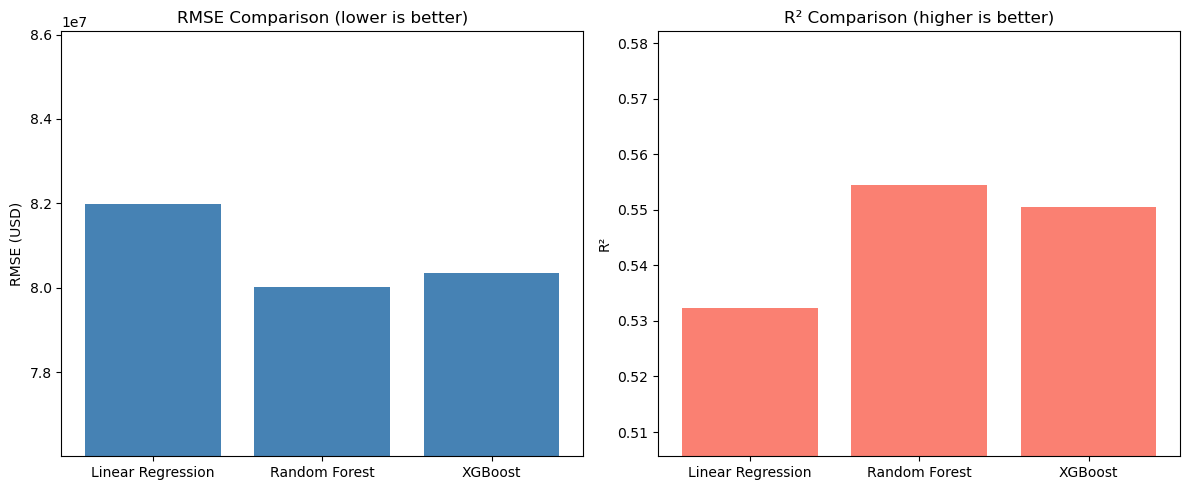

In [17]:
#02 Models Performance Comparison Bar Chart
model_names = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, lr_pred_test)),
    np.sqrt(mean_squared_error(y_test, rf_pred_test)),
    np.sqrt(mean_squared_error(y_test, xgb_pred_test))
]

r2_scores = [
    r2_score(y_test, lr_pred_test),
    r2_score(y_test, rf_pred_test),
    r2_score(y_test, xgb_pred_test)
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

#RMSE comparison
axes[0].bar(model_names, rmse_scores, color='steelblue')
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_ylim(min(rmse_scores) * 0.95, max(rmse_scores) * 1.05)

#R² comparison
axes[1].bar(model_names, r2_scores, color='salmon')
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(min(r2_scores) * 0.95, max(r2_scores) * 1.05)

plt.tight_layout()
plt.show()

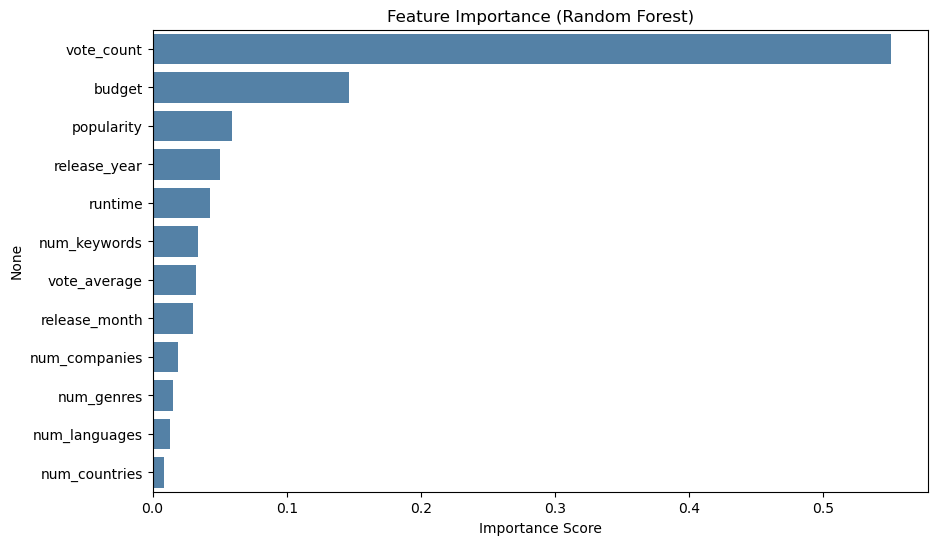

In [18]:
#03 Feature Importance (Random Forest)
feature_importance = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

## Section 10 

### Summary 
In this project, I built three machine learning models to predict movie revenue using the TMDB 5000 Movies Dataset. After data cleaning, JSON parsing, and feature extracting, I trained and evaluated the following models:

**Linear Regression**
- RMSE: $81,976,417 | RSE: 0.6839 | R²: 0.5322

**Random Forest** 
- RMSE: $80,009,477 | RSE: 0.6675 | R²: 0.5544

**XGBoost**
- RMSE: $80,357,526 | RSE: 0.6704 | R²: 0.5505

### Key Findings
- `vote_count`, `budget`, and `popularity` are the strongest predictors of revenue
- Feature engineering successfully extracted useful numeric features such as `num_keywords`,`num_companies`, and `num_genres` from JSON columns
- Binary features based on release timing (`is_friday`, `is_summer`, `is_holiday`) and language (`is_english`) contributed minimally and were removed
- This suggests that a movie's financial success is primarily driven by its production budget, popularity, and audience engagement rather than when or where it is released
- All models explain approximately 55%% of revenue variation
- Random Forest achieved the best overall performance

### Why Predictions Are Not Perfectly Accurate
- Missing features such as marketing budget, 